<a href="https://colab.research.google.com/github/DeepanshuSharma1607/tech_stuck/blob/main/spam_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "combined_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "purusinghvi/email-spam-classification-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_7939/819419524.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'email-spam-classification-dataset' dataset.
First 5 records:    label                                               text
0      1  ounce feather bowl hummingbird opec moment ala...
1      1  wulvob get your medircations online qnb ikud v...
2      0   computer connection from cnn com wednesday es...
3      1  university degree obtain a prosperous future m...
4      0  thanks for all your answers guys i know i shou...


In [ ]:
df

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...
...,...,...
83443,0,hi given a date how do i get the last date of ...
83444,1,now you can order software on cd or download i...
83445,1,dear valued member canadianpharmacy provides a...
83446,0,subscribe change profile contact us long term ...


In [ ]:
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [ ]:
# 1. Pre-load outside the loop
stop_words = set(stopwords.words('english'))
corpus = []

for i in range(0, df.shape[0]):
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    review = review.lower().split()
    # 2. Use the 'stop_words' variable here
    review = [ps.stem(word) for word in review if not word in stop_words]
    review = ' '.join(review)
    corpus.append(review)

In [ ]:
corpus

['ounc feather bowl hummingbird opec moment alabast valkyri dyad bread flack desper iambic hadron heft quell yoghurt bunkmat divert afterimag',
 'wulvob get medirc onlin qnb ikud viagra escapenumb escapenumb levitra escapenumb escapenumb ciali escapenumb escapenumb imitrex escapenumb escapenumb flonax escapenumb escapenumb ultram escapenumb escapenumb vioxx escapenumb escapenumb ambien escapenumb escapenumb valium escapenumb escapenumb xannax escapenumb escapenumb soma escapenumb meridia escapenumb escapenumb escapenumb escapenumb cysfrt ever stop wonder much averag man pay mediecin ap painkil drug improv qualiti life weight reduc tablet mani escapenumb wors mediucin cost lot brand rfwur intrest http dmvrwm remunerativ net dfuaeirxygiq visit websit escapenumb',
 'comput connect cnn com wednesday escapenumb may escapenumb escapenumb escapenumb escapenumb pm edt report next gener toy read brain wave googl expand person youtub win webbi old fashion rabbit ear laptop review next gener toy 

In [ ]:
#create bag of words
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=100,binary=True)
#for binary bag of words enable binary


In [ ]:
X=cv.fit_transform(corpus).toarray()

In [ ]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
corpus1 = []

for i in range(0, df.shape[0]):
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    review = review.lower().split()
    # 2. Use the 'stop_words' variable here
    review = [lemmatizer.lemmatize(word,pos='v') for word in review if not word in stop_words]
    review = ' '.join(review)
    corpus1.append(review)

In [ ]:
#create bag of words
from sklearn.feature_extraction.text import CountVectorizer
cv_=CountVectorizer(max_features=100,binary=True)
#for binary bag of words enable binary


In [ ]:
X1=cv_.fit_transform(corpus1).toarray()

In [ ]:
X1

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
cv.vocabulary_

{'get': np.int64(28),
 'escapenumb': np.int64(19),
 'much': np.int64(50),
 'mani': np.int64(47),
 'http': np.int64(34),
 'com': np.int64(8),
 'may': np.int64(48),
 'pm': np.int64(62),
 'gener': np.int64(27),
 'read': np.int64(69),
 'compani': np.int64(11),
 'use': np.int64(91),
 'help': np.int64(32),
 'make': np.int64(45),
 'www': np.int64(98),
 'html': np.int64(33),
 'name': np.int64(51),
 'news': np.int64(54),
 'receiv': np.int64(70),
 'email': np.int64(17),
 'result': np.int64(72),
 'set': np.int64(79),
 'manag': np.int64(46),
 'click': np.int64(6),
 'servic': np.int64(78),
 'escapelong': np.int64(18),
 'unsubscrib': np.int64(89),
 'list': np.int64(40),
 'mail': np.int64(43),
 'one': np.int64(57),
 'time': np.int64(86),
 'right': np.int64(73),
 'come': np.int64(9),
 'day': np.int64(16),
 'includ': np.int64(35),
 'thank': np.int64(84),
 'know': np.int64(37),
 'would': np.int64(96),
 'org': np.int64(59),
 'file': np.int64(21),
 'also': np.int64(0),
 'wrote': np.int64(97),
 'question':

In [ ]:
cv_.vocabulary_

{'get': np.int64(30),
 'escapenumber': np.int64(22),
 'much': np.int64(54),
 'many': np.int64(50),
 'http': np.int64(36),
 'com': np.int64(10),
 'may': np.int64(51),
 'pm': np.int64(66),
 'read': np.int64(72),
 'company': np.int64(13),
 'use': np.int64(92),
 'help': np.int64(34),
 'make': np.int64(49),
 'www': np.int64(99),
 'html': np.int64(35),
 'line': np.int64(43),
 'name': np.int64(55),
 'news': np.int64(58),
 'receive': np.int64(73),
 'email': np.int64(19),
 'result': np.int64(75),
 'click': np.int64(8),
 'service': np.int64(81),
 'escapelong': np.int64(21),
 'unsubscribe': np.int64(90),
 'list': np.int64(44),
 'mail': np.int64(47),
 'one': np.int64(61),
 'time': np.int64(87),
 'right': np.int64(76),
 'money': np.int64(53),
 'come': np.int64(11),
 'day': np.int64(18),
 'include': np.int64(37),
 'thank': np.int64(85),
 'know': np.int64(39),
 'would': np.int64(97),
 'org': np.int64(63),
 'file': np.int64(24),
 'also': np.int64(0),
 'write': np.int64(98),
 'question': np.int64(71),


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=200,binary=True,ngram_range=(2,3))
cv_=CountVectorizer(max_features=200,binary=True,ngram_range=(2,3))

In [ ]:
X=cv.fit_transform(corpus).toarray()
cv.vocabulary_

{'escapenumb escapenumb': np.int64(47),
 'escapenumb escapenumb escapenumb': np.int64(49),
 'escapenumb may': np.int64(57),
 'may escapenumb': np.int64(117),
 'escapenumb pm': np.int64(62),
 'http www': np.int64(95),
 'com escapenumb': np.int64(24),
 'receiv email': np.int64(152),
 'com escapelong': np.int64(23),
 'escapelong escapelong': np.int64(41),
 'cgi bin': np.int64(15),
 'speedi uwaterloo': np.int64(172),
 'uwaterloo ca': np.int64(185),
 'right reserv': np.int64(161),
 'escapenumb may escapenumb': np.int64(58),
 'may escapenumb escapenumb': np.int64(118),
 'escapenumb escapenumb pm': np.int64(51),
 'speedi uwaterloo ca': np.int64(173),
 'escapenumb day': np.int64(44),
 'jun escapenumb': np.int64(97),
 'jun escapenumb escapenumb': np.int64(98),
 'escapelong escapenumb': np.int64(43),
 'june escapenumb': np.int64(99),
 'escapenumb year': np.int64(67),
 'go http': np.int64(71),
 'help pleas': np.int64(78),
 'altern html': np.int64(2),
 'html version': np.int64(87),
 'version delet

In [ ]:
X1=cv_.fit_transform(corpus1).toarray()
cv_.vocabulary_

{'escapenumber escapenumber': np.int64(47),
 'escapenumber escapenumber escapenumber': np.int64(49),
 'escapenumber may': np.int64(57),
 'may escapenumber': np.int64(116),
 'escapenumber pm': np.int64(62),
 'http www': np.int64(92),
 'com escapenumber': np.int64(24),
 'receive email': np.int64(152),
 'com escapelong': np.int64(23),
 'escapelong escapelong': np.int64(41),
 'cgi bin': np.int64(15),
 'speedy uwaterloo': np.int64(172),
 'uwaterloo ca': np.int64(185),
 'right reserve': np.int64(161),
 'escapenumber may escapenumber': np.int64(58),
 'may escapenumber escapenumber': np.int64(117),
 'escapenumber escapenumber pm': np.int64(51),
 'speedy uwaterloo ca': np.int64(173),
 'jun escapenumber': np.int64(96),
 'jun escapenumber escapenumber': np.int64(97),
 'escapelong escapenumber': np.int64(43),
 'june escapenumber': np.int64(98),
 'go http': np.int64(70),
 'help please': np.int64(77),
 'alternative html': np.int64(2),
 'html version': np.int64(86),
 'version delete': np.int64(186),


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=100,ngram_range=(2,2))
X=tfidf.fit_transform(corpus1)

In [ ]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 356884 stored elements and shape (83448, 100)>

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,df['label'],random_state=42,test_size=0.2)

In [ ]:
import lightgbm as lgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

# 1. Upgrade your Vectorizer (Crucial step)
# Increasing max_features from 100 to 5000 gives the model more 'vocabulary'
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(corpus)

# 2. Re-split with the better features
x_train, x_test, y_train, y_test = train_test_split(X_tfidf, df['label'], test_size=0.2, random_state=42)

# 3. Initialize LightGBM with optimized parameters
lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,      # More trees, but we use early stopping
    learning_rate=0.05,     # Smaller steps for better generalization
    num_leaves=64,          # Complexity of the trees
    max_depth=10,           # Prevents overfitting on specific emails
    feature_fraction=0.8,   # Randomly selects 80% of features for each tree
    bagging_fraction=0.8,   # Randomly selects 80% of data for each tree
    importance_type='gain'
)

# 4. Train the model
lgbm_model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    eval_metric='binary_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 5. Predict and Evaluate
y_pred_train=lgbm_model.predict(x_train)
y_pred = lgbm_model.predict(x_test)
print(f"train Accuracy: {accuracy_score(y_train, y_pred_train)}")
print(classification_report(y_test, y_pred))
print(f"test Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 35158, number of negative: 31600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 8.422537 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 837120
[LightGBM] [Info] Number of data points in the train set: 66758, number of used features: 4951
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
train Accuracy: 0.9979478114982474
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7938
           1       0.98      0.99      0.99      8752

    accuracy                           0.99     16690
   macro avg       0.99      0.99      0.99     16690
weighted avg       0.99      0.99      0.99     16690

test Accuracy: 0.9857998801677651
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7938
           1       0.98      0.99      0.99      8752

    accuracy                           0.99     16690
   macro avg       0.99      0.99      0.99     16690
weighted avg       0.99      0.99      0.99     16690



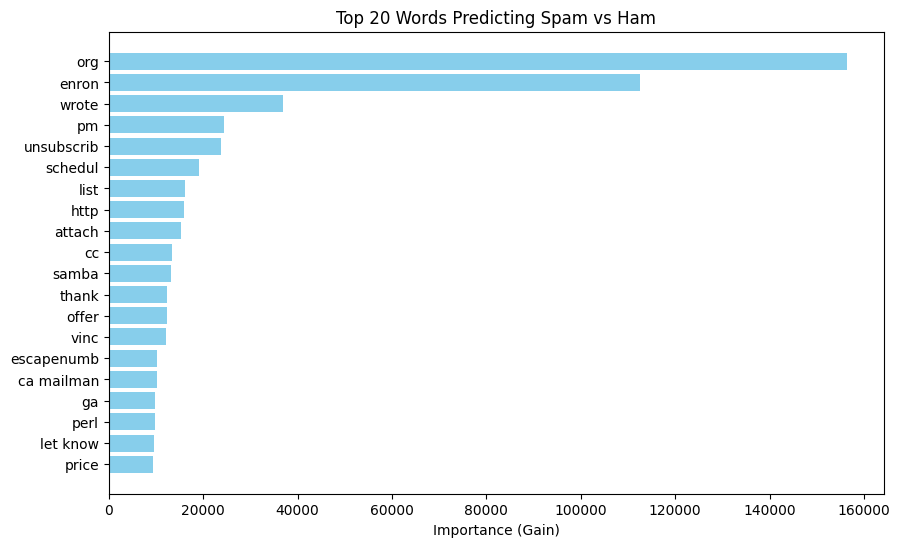

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = lgbm_model.feature_importances_
feature_names = tfidf.get_feature_names_out()

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Word': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Word'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance (Gain)')
plt.title('Top 20 Words Predicting Spam vs Ham')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
s="Hello deepashu how are you hope you are fine"

In [ ]:
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
corpus2 = []
review = re.sub('[^a-zA-Z]', ' ', s)
review = review.lower().split()
review = [lemmatizer.lemmatize(word,pos='v') for word in review if not word in stop_words]
review = ' '.join(review)
corpus2.append(review)

In [ ]:
(df['label']==0).sum()/(df['label']==1).sum()

np.float64(0.9004327032566614)

In [ ]:
corpus2

['hello deepashu hope fine']

In [ ]:
import lightgbm as lgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

# The tfidf vectorizer and lgbm_model were already fitted in cell 'vR_qNJMqk5TR'.
# We should use that already fitted tfidf object to transform the new text.

# Re-instantiate and re-fit TfidfVectorizer with the parameters used for training
# This is necessary because the `tfidf` variable was overwritten or is in an inconsistent state.
# In a real-world scenario, you would save and load the fitted vectorizer.
tfidf_for_prediction = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
tfidf_for_prediction.fit(corpus) # Fit on the full training corpus

X_tfidf_for_prediction = tfidf_for_prediction.transform(corpus2)

# 5. Predict and Evaluate
y_pred_single_input = lgbm_model.predict(X_tfidf_for_prediction)
y_pred_single_input

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([1])

### Inspecting Features for 'Hello deepashu how are you hope you are fine'

Let's look at the processed text and the specific TF-IDF features that are activated by this input, and then see their importance in our trained model.

In [ ]:
# Get the TF-IDF representation of the input text
X_single_input = tfidf_for_prediction.transform(corpus2)

# Get the feature names corresponding to the non-zero elements in the input vector
feature_indices = X_single_input.nonzero()[1]
activated_feature_names = [tfidf_for_prediction.get_feature_names_out()[i] for i in feature_indices]

# Get the importance of these activated features from the trained LightGBM model
feature_importances = lgbm_model.feature_importances_
activated_feature_importances = {name: feature_importances[tfidf_for_prediction.vocabulary_[name]] for name in activated_feature_names if name in tfidf_for_prediction.vocabulary_}

print("Processed input text:", corpus2[0])
print("\nActivated TF-IDF features and their importances:")
for feature, importance in sorted(activated_feature_importances.items(), key=lambda item: item[1], reverse=True):
    print(f"  - {feature}: {importance:.2f}")

if not activated_feature_names:
    print("No relevant features found in the input text that are part of the model's vocabulary.")

Processed input text: hello deepashu hope fine

Activated TF-IDF features and their importances:
  - hello: 837.01
  - hope: 197.44
  - fine: 31.60


The output above shows which words or n-grams from your input sentence (`hello deepashu hope fine`) are present in the model's vocabulary, and their relative importance for classification. If `deepashu` or other common words were assigned high importance for spam, it might be due to statistical correlation in the training data rather than a direct semantic link.

To make it classify correctly (as ham, label 0), here are some potential approaches:

1.  **Review the Training Data**: Investigate if any non-spam emails in your original `df` accidentally contained words like 'deepashu' or 'fine' that were marked as spam, or if spam emails frequently used seemingly innocuous terms that are now causing misclassifications.

2.  **Increase `max_features`**: While we already use 5000, sometimes more context from even rarer words can help. You could try increasing `max_features` in the `TfidfVectorizer` to a higher number (e.g., 10,000 or more) to see if it captures more discriminative features, though this comes with increased computational cost and risk of overfitting.

3.  **Refine Preprocessing**: Experiment with different stemming/lemmatization techniques or stopword lists. For example, you used stemming for `corpus` and lemmatization for `corpus1`. It might be beneficial to re-evaluate which preprocessing method works best.

4.  **Hyperparameter Tuning**: Further optimize the LightGBM model's hyperparameters (`num_leaves`, `max_depth`, `learning_rate`, etc.) using techniques like GridSearchCV or RandomizedSearchCV to find a better balance between precision and recall, reducing false positives.

5.  **Add More Features (Feature Engineering)**: Beyond TF-IDF, you could add features like:
    *   Length of the email.
    *   Number of exclamation marks, dollar signs, or unusual capitalization.
    *   Presence of specific spam-related keywords (e.g., 'free', 'win', 'guarantee') that are not captured well by TF-IDF alone.

For this specific case, if no features show high importance for 'spam', it suggests the current words aren't strongly driving the spam classification, and it might be a general bias of the model or due to the absence of strong 'ham' indicators.